## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

!pip install -q wandb
!pip install -q -U transformers>=4.41 peft sentencepiece accelerate torchao

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import re
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForMultipleChoice
from peft import LoraConfig, get_peft_model, TaskType

import wandb
from kaggle_secrets import UserSecretsClient

sns.set_style("whitegrid")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


## Configuration

One global config for shared settings, one per model for its own hyperparameters.

In [3]:
class CFG:
    DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED       = 42
    VAL_SPLIT  = 0.2
    GRAD_CLIP  = 1.0
    N_OPTIONS  = 5
    USE_WANDB  = False
    WANDB_PROJECT = "24f2008341-t22026"
    DATA_DIR   = "/kaggle/input/competitions/smart-mcq-solver-challenge"


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(CFG.SEED)

N_GPUS = torch.cuda.device_count()
print(f"Device: {CFG.DEVICE}")
print(f"GPUs visible: {N_GPUS}")
print(f"Seeded with: {CFG.SEED}")

Device: cuda
GPUs visible: 2
Seeded with: 42


In [4]:
if CFG.USE_WANDB:
    try:
        secrets = UserSecretsClient()
        wandb.login(key=secrets.get_secret("WANDB_API_KEY"))
        os.environ["HF_TOKEN"] = secrets.get_secret("HF_TOKEN")
        print(f"Wandb ready, version {wandb.__version__}")
    except Exception as e:
        CFG.USE_WANDB = False
        print(f"Wandb disabled: {e}")

## Data

The train/val split is made once here so every model sees exactly the same rows in the same order.

In [5]:
train_full = pd.read_csv(f"{CFG.DATA_DIR}/train.csv")
test_df    = pd.read_csv(f"{CFG.DATA_DIR}/test.csv")
sample_df  = pd.read_csv(f"{CFG.DATA_DIR}/sample_submission.csv")

val_size   = int(CFG.VAL_SPLIT * len(train_full))
train_df   = train_full.iloc[:-val_size].reset_index(drop=True)
val_df     = train_full.iloc[-val_size:].reset_index(drop=True)

print(f"train: {train_df.shape}  val: {val_df.shape}  test: {test_df.shape}")
print(f"\nAnswer distribution:\n{train_full['answer'].value_counts().sort_index()}")

train: (1600, 8)  val: (400, 8)  test: (500, 7)

Answer distribution:
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


## Metric

MAP@3 scores the top 3 ranked options, giving 1, 1/2 or 1/3 depending on where the correct answer lands.

In [6]:
LABEL_MAP    = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}


def map_at_3(scores, labels):
    ranked = torch.argsort(scores, dim=-1, descending=True)[:, :3]
    hits   = (ranked == labels.unsqueeze(1))
    weights = torch.tensor([1.0, 0.5, 1.0 / 3.0])
    return float((hits.float() * weights).sum(dim=1).mean())


_s = torch.tensor([[9.0, 1.0, 2.0, 3.0, 4.0], [1.0, 2.0, 9.0, 3.0, 4.0]])
_l = torch.tensor([0, 4])
print(f"map_at_3 sanity check: {map_at_3(_s, _l):.4f} (expected 0.7500)")

map_at_3 sanity check: 0.7500 (expected 0.7500)


## Word Level Vocabulary and Dataset

Used by the two recurrent models. Text is lowercased, stripped of punctuation and mapped to integer ids.

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

class Vocabulary:
    """Maps words to integer ids. PAD is 0, UNK is 1."""

    PAD_ID = 0
    UNK_ID = 1

    def __init__(self, max_vocab=30000):
        self.max_vocab = max_vocab
        self.word2id   = {"<PAD>": 0, "<UNK>": 1}
        self.id2word   = {0: "<PAD>", 1: "<UNK>"}

    def build(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(tokenize(text))

        most_common = counter.most_common(self.max_vocab - 2)
        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2id[word] = idx
            self.id2word[idx]  = word

        print(f"Vocabulary built: {len(self.word2id):,} words")
        print(f"Most common: {[w for w, _ in most_common[:10]]}")

    def encode(self, text, max_len):
        """Returns padded ids plus the true length. Empty text falls back to a
        single UNK so that pack_padded_sequence never sees a length of zero."""
        tokens = tokenize(text)
        ids    = [self.word2id.get(w, self.UNK_ID) for w in tokens][:max_len]
        if len(ids) == 0:
            ids = [self.UNK_ID]
        length = len(ids)
        ids    = ids + [self.PAD_ID] * (max_len - length)
        return ids, length

In [8]:
class WordMCQDataset(Dataset):
    """Encodes the whole frame once up front so workers are not needed."""

    def __init__(self, df, vocab, max_len_prompt, max_len_option, has_labels=True):
        df = df.reset_index(drop=True)
        self.has_labels = has_labels

        p_ids, p_lens, o_ids, o_lens, labels = [], [], [], [], []
        for _, row in df.iterrows():
            pi, pl = vocab.encode(row["prompt"], max_len_prompt)
            p_ids.append(pi)
            p_lens.append(pl)

            oi, ol = [], []
            for opt in "ABCDE":
                ids, length = vocab.encode(str(row[opt]), max_len_option)
                oi.append(ids)
                ol.append(length)
            o_ids.append(oi)
            o_lens.append(ol)

            if has_labels:
                labels.append(LABEL_MAP[row["answer"]])

        self.prompt_ids  = torch.tensor(p_ids,  dtype=torch.long)
        self.prompt_len  = torch.tensor(p_lens, dtype=torch.long)
        self.option_ids  = torch.tensor(o_ids,  dtype=torch.long)
        self.option_lens = torch.tensor(o_lens, dtype=torch.long)
        self.labels      = torch.tensor(labels, dtype=torch.long) if has_labels else None

    def __len__(self):
        return len(self.prompt_ids)

    def __getitem__(self, idx):
        sample = {
            "prompt_ids" : self.prompt_ids[idx],
            "prompt_len" : self.prompt_len[idx],
            "option_ids" : self.option_ids[idx],
            "option_lens": self.option_lens[idx],
        }
        if self.has_labels:
            sample["label"] = self.labels[idx]
        return sample

## Transformer Dataset

Used by the DeBERTa model. Each option is tokenized as a pair with the prompt.

In [9]:
class HFMCQDataset(Dataset):
    """Returns input_ids and attention_mask shaped (5, max_len), one row per option."""

    def __init__(self, df, tokenizer, max_len, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        prompt  = str(row["prompt"])
        options = [str(row[opt]) for opt in "ABCDE"]

        enc = self.tokenizer(
            [prompt] * 5, options,
            truncation=True, max_length=self.max_len,
            padding="max_length", return_tensors="pt",
        )

        sample = {
            "input_ids"     : enc["input_ids"],
            "attention_mask": enc["attention_mask"],
        }
        if self.has_labels:
            sample["label"] = torch.tensor(LABEL_MAP[row["answer"]], dtype=torch.long)
        return sample

## Model Definitions

Every model exposes the same contract: forward returns a (batch, 5) logit tensor, one score per option.

### Model 1: BiLSTM Siamese

One shared encoder runs over the prompt and each option. The scorer sees [prompt, option, prompt - option].

In [10]:
class LSTMEncoder(nn.Module):
    """Encodes a padded token sequence into a fixed vector using the final hidden state."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout    = nn.Dropout(dropout)
        self.output_dim = hidden_dim * 2

    def forward(self, token_ids, lengths):
        emb    = self.dropout(self.embedding(token_ids))
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        # hidden is (num_layers * 2, batch, hidden_dim). Take the final layer only.
        out = torch.cat([hidden[-2], hidden[-1]], dim=-1)
        return self.dropout(out)


class BiLSTMSiamese(nn.Module):

    def __init__(self, vocab_size, cfg):
        super().__init__()
        self.encoder = LSTMEncoder(
            vocab_size, cfg.EMBED_DIM, cfg.HIDDEN_DIM,
            cfg.NUM_LAYERS, cfg.DROPOUT,
        )
        enc_dim = self.encoder.output_dim
        self.scorer = nn.Sequential(
            nn.Linear(3 * enc_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(128, 1),
        )

    def forward(self, prompt_ids, prompt_len, option_ids, option_lens):
        p_repr = self.encoder(prompt_ids, prompt_len)
        logits = []
        for i in range(CFG.N_OPTIONS):
            o_repr = self.encoder(option_ids[:, i, :], option_lens[:, i])
            inter  = torch.cat([p_repr, o_repr, p_repr - o_repr], dim=-1)
            logits.append(self.scorer(inter))
        return torch.cat(logits, dim=-1)

### Model 2: BiGRU with attention pooling

Same Siamese idea but pools every timestep with learned attention instead of taking the last state, and adds an elementwise product to the interaction vector.

In [11]:
class GRUAttentionEncoder(nn.Module):
    """Encodes a padded token sequence by attention pooling over all timesteps."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_id=0):
        super().__init__()
        self.pad_id    = pad_id
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.attn       = nn.Linear(hidden_dim * 2, 1)
        self.dropout    = nn.Dropout(dropout)
        self.output_dim = hidden_dim * 2

    def forward(self, token_ids, lengths):
        emb      = self.dropout(self.embedding(token_ids))
        packed   = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _   = self.gru(packed)
        out, _   = pad_packed_sequence(out, batch_first=True, total_length=token_ids.size(1))

        mask     = (token_ids != self.pad_id)
        scores   = self.attn(out).squeeze(-1).masked_fill(~mask, -1e9)
        weights  = torch.softmax(scores, dim=-1).unsqueeze(-1)
        pooled   = (out * weights).sum(dim=1)
        return self.dropout(pooled)


class BiGRUAttention(nn.Module):

    def __init__(self, vocab_size, cfg):
        super().__init__()
        self.encoder = GRUAttentionEncoder(
            vocab_size, cfg.EMBED_DIM, cfg.HIDDEN_DIM,
            cfg.NUM_LAYERS, cfg.DROPOUT,
        )
        enc_dim = self.encoder.output_dim
        self.scorer = nn.Sequential(
            nn.Linear(4 * enc_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(128, 1),
        )

    def forward(self, prompt_ids, prompt_len, option_ids, option_lens):
        p_repr = self.encoder(prompt_ids, prompt_len)
        logits = []
        for i in range(CFG.N_OPTIONS):
            o_repr = self.encoder(option_ids[:, i, :], option_lens[:, i])
            inter  = torch.cat([p_repr, o_repr, p_repr - o_repr, p_repr * o_repr], dim=-1)
            logits.append(self.scorer(inter))
        return torch.cat(logits, dim=-1)

### Model 3: DeBERTa v3 large with LoRA

The base weights stay frozen. Only the LoRA adapters and the classifier head are trained.

In [12]:
class DebertaLoRA(nn.Module):
    """Wraps a PEFT multiple choice model so that forward returns a plain logit tensor."""

    def __init__(self, cfg):
        super().__init__()
        base = AutoModelForMultipleChoice.from_pretrained(
            cfg.MODEL_NAME, torch_dtype=torch.float32
        )
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=cfg.LORA_R,
            lora_alpha=cfg.LORA_ALPHA,
            lora_dropout=cfg.LORA_DROPOUT,
            target_modules=cfg.TARGET_MODULES,
            modules_to_save=["classifier", "pooler"],
        )
        self.model = get_peft_model(base, lora_config)

        # GradScaler requires fp32 master weights for anything it steps.
        for p in self.model.parameters():
            if p.requires_grad:
                p.data = p.data.float()

    def forward(self, input_ids, attention_mask):
        return self.model(input_ids=input_ids, attention_mask=attention_mask).logits

    def print_trainable(self):
        self.model.print_trainable_parameters()

## Trainer

One training loop for all three models. batch_kind decides how a batch is unpacked, so the recurrent and transformer models share everything else.

In [13]:
class Trainer:
    """Handles optimizer setup, multi GPU wrapping, the epoch loop and best checkpoint tracking."""

    def __init__(self, model, name, batch_kind, epochs, lr,
                 grad_accum=1, use_amp=False, embed_lr_ratio=None,
                 scheduler="plateau", steps_per_epoch=None, wandb_config=None):

        self.name        = name
        self.batch_kind  = batch_kind
        self.epochs      = epochs
        self.grad_accum  = grad_accum
        self.use_amp     = use_amp
        self.device      = CFG.DEVICE
        self.sched_kind  = scheduler

        # base_model is always the unwrapped module. DataParallel hides it behind .module.
        self.base_model = model
        self.model = nn.DataParallel(model) if N_GPUS > 1 else model
        self.model = self.model.to(self.device)

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = self._build_optimizer(lr, embed_lr_ratio)
        self.scaler    = torch.cuda.amp.GradScaler(enabled=use_amp)

        if scheduler == "onecycle":
            total = max(steps_per_epoch * epochs, 1)
            self.scheduler = torch.optim.lr_scheduler.OneCycleLR(
                self.optimizer, max_lr=lr, total_steps=total
            )
        else:
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer, mode="max", factor=0.5, patience=2
            )

        self.history      = []
        self.best_val_map = 0.0
        self.best_state   = None
        self.wandb_config = wandb_config
        self.run          = None

    def _build_optimizer(self, lr, embed_lr_ratio):
        if embed_lr_ratio is None:
            params = [p for p in self.base_model.parameters() if p.requires_grad]
            return torch.optim.AdamW(params, lr=lr)

        embed_params = list(self.base_model.encoder.embedding.parameters())
        embed_ids    = {id(p) for p in embed_params}
        other        = [p for p in self.base_model.parameters() if id(p) not in embed_ids]
        return torch.optim.Adam([
            {"params": embed_params, "lr": lr * embed_lr_ratio},
            {"params": other,        "lr": lr},
        ])

    def _forward(self, batch):
        if self.batch_kind == "word":
            return self.model(
                batch["prompt_ids"].to(self.device),
                batch["prompt_len"].to(self.device),
                batch["option_ids"].to(self.device),
                batch["option_lens"].to(self.device),
            )
        return self.model(
            batch["input_ids"].to(self.device),
            batch["attention_mask"].to(self.device),
        )

    def _train_epoch(self, loader, epoch):
        self.model.train()
        total_loss, all_logits, all_labels = 0.0, [], []
        self.optimizer.zero_grad()

        pbar = tqdm(loader, desc=f"{self.name} epoch {epoch}/{self.epochs}",
                    leave=False, dynamic_ncols=True)

        for step, batch in enumerate(pbar):
            labels = batch["label"].to(self.device)

            with torch.cuda.amp.autocast(enabled=self.use_amp):
                logits = self._forward(batch)
                loss   = self.criterion(logits, labels) / self.grad_accum

            self.scaler.scale(loss).backward()

            is_last = (step + 1) == len(loader)
            if (step + 1) % self.grad_accum == 0 or is_last:
                self.scaler.unscale_(self.optimizer)
                nn.utils.clip_grad_norm_(
                    [p for p in self.model.parameters() if p.requires_grad], CFG.GRAD_CLIP
                )
                self.scaler.step(self.optimizer)
                self.scaler.update()
                if self.sched_kind == "onecycle":
                    self.scheduler.step()
                self.optimizer.zero_grad()

            batch_loss  = loss.item() * self.grad_accum
            total_loss += batch_loss
            all_logits.append(logits.detach().float().cpu())
            all_labels.append(labels.detach().cpu())
            pbar.set_postfix(loss=f"{batch_loss:.4f}",
                             lr=f"{self.optimizer.param_groups[-1]['lr']:.2e}")

        logits = torch.cat(all_logits)
        labels = torch.cat(all_labels)
        return total_loss / len(loader), map_at_3(logits, labels)

    @torch.no_grad()
    def predict(self, loader, has_labels=True):
        """Returns loss, map3, logits and labels. Loss and map3 are None without labels."""
        self.model.to(self.device)
        self.model.eval()
        total_loss, all_logits, all_labels = 0.0, [], []

        for batch in tqdm(loader, desc=f"{self.name} predict", leave=False, dynamic_ncols=True):
            with torch.cuda.amp.autocast(enabled=self.use_amp):
                logits = self._forward(batch)
            logits = logits.float()

            if has_labels:
                labels = batch["label"].to(self.device)
                total_loss += self.criterion(logits, labels).item()
                all_labels.append(labels.cpu())
            all_logits.append(logits.cpu())

        logits = torch.cat(all_logits)
        if not has_labels:
            return None, None, logits, None

        labels = torch.cat(all_labels)
        return total_loss / len(loader), map_at_3(logits, labels), logits, labels

    def _snapshot(self):
        """Keeps only trainable tensors, which for the LoRA model avoids copying the frozen backbone."""
        trainable = {n for n, p in self.base_model.named_parameters() if p.requires_grad}
        return {k: v.detach().clone().cpu()
                for k, v in self.base_model.state_dict().items() if k in trainable}

    def fit(self, train_loader, val_loader):
        if CFG.USE_WANDB and self.wandb_config is not None:
            self.run = wandb.init(project=CFG.WANDB_PROJECT, name=self.name,
                                  config=self.wandb_config, tags=[self.name], reinit=True)

        for epoch in range(1, self.epochs + 1):
            tr_loss, tr_map = self._train_epoch(train_loader, epoch)
            vl_loss, vl_map, _, _ = self.predict(val_loader)

            if self.sched_kind == "plateau":
                self.scheduler.step(vl_map)

            is_best = vl_map > self.best_val_map
            if is_best:
                self.best_val_map = vl_map
                self.best_state   = self._snapshot()

            marker = "  *best" if is_best else ""
            print(f"[{self.name}] epoch {epoch:02d}/{self.epochs}  "
                  f"tr_loss={tr_loss:.4f}  tr_map={tr_map:.4f}  "
                  f"vl_loss={vl_loss:.4f}  vl_map={vl_map:.4f}{marker}")

            self.history.append({"epoch": epoch, "tr_loss": tr_loss, "tr_map": tr_map,
                                 "vl_loss": vl_loss, "vl_map": vl_map})

            if self.run is not None:
                wandb.log({"epoch": epoch, "train/loss": tr_loss, "train/map3": tr_map,
                           "val/loss": vl_loss, "val/map3": vl_map,
                           "val/map3_best": self.best_val_map})

        # Restore the best epoch so later predictions do not use the last epoch by accident.
        if self.best_state is not None:
            self.base_model.load_state_dict(self.best_state, strict=False)

        if self.run is not None:
            wandb.summary["best_val_map3"] = self.best_val_map
            wandb.finish()
            self.run = None

        print(f"[{self.name}] best val MAP@3: {self.best_val_map:.4f}")
        return self.history

In [14]:
def plot_history(history, title):
    """Loss and MAP@3 curves for a single model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = [h["epoch"] for h in history]

    ax1.plot(epochs, [h["tr_loss"] for h in history], marker="o", label="train")
    ax1.plot(epochs, [h["vl_loss"] for h in history], marker="o", label="val")
    ax1.set_title(f"{title}: loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("cross entropy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [h["tr_map"] for h in history], marker="o", label="train")
    ax2.plot(epochs, [h["vl_map"] for h in history], marker="o", label="val")
    ax2.axhline(0.4213, linestyle="--", color="gray", label="random baseline")
    ax2.set_title(f"{title}: MAP@3")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("MAP@3")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Model 1: BiLSTM Siamese

In [15]:
class LSTMCfg:
    NAME           = "bilstm-siamese"
    MAX_VOCAB      = 30000
    MAX_LEN_PROMPT = 64
    MAX_LEN_OPTION = 128
    EMBED_DIM      = 300
    HIDDEN_DIM     = 256
    NUM_LAYERS     = 2
    DROPOUT        = 0.3
    BATCH_SIZE     = 32 * max(N_GPUS, 1)
    EPOCHS         = 15
    LR             = 3e-4
    EMBED_LR_RATIO = 0.1


def as_dict(cfg):
    return {k: v for k, v in vars(cfg).items() if not k.startswith("__")}


all_texts = []
for _, row in train_df.iterrows():
    all_texts.append(row["prompt"])
    for opt in "ABCDE":
        all_texts.append(str(row[opt]))

vocab = Vocabulary(max_vocab=LSTMCfg.MAX_VOCAB)
vocab.build(all_texts)


def make_word_loader(df, has_labels, shuffle, batch_size):
    ds = WordMCQDataset(df, vocab, LSTMCfg.MAX_LEN_PROMPT,
                        LSTMCfg.MAX_LEN_OPTION, has_labels=has_labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


word_train_loader = make_word_loader(train_df, True,  True,  LSTMCfg.BATCH_SIZE)
word_val_loader   = make_word_loader(val_df,   True,  False, LSTMCfg.BATCH_SIZE)
word_test_loader  = make_word_loader(test_df,  False, False, LSTMCfg.BATCH_SIZE)

print(f"word loaders: train {len(word_train_loader)}  "
      f"val {len(word_val_loader)}  test {len(word_test_loader)} batches")

Vocabulary built: 2,975 words
Most common: ['the', 'of', 'a', 'is', 'and', 'in', 'to', 'that', 'by', 'an']
word loaders: train 25  val 7  test 8 batches


In [16]:
seed_everything(CFG.SEED)

lstm_model = BiLSTMSiamese(len(vocab.word2id), LSTMCfg)
print(f"trainable params: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

lstm_trainer = Trainer(
    model          = lstm_model,
    name           = LSTMCfg.NAME,
    batch_kind     = "word",
    epochs         = LSTMCfg.EPOCHS,
    lr             = LSTMCfg.LR,
    embed_lr_ratio = LSTMCfg.EMBED_LR_RATIO,
    scheduler      = "plateau",
    wandb_config   = as_dict(LSTMCfg),
)

lstm_trainer.fit(word_train_loader, word_val_loader)

trainable params: 4,466,005


bilstm-siamese epoch 1/15:   0%|          | 0/25 [00:00<?, ?it/s]

bilstm-siamese predict:   0%|          | 0/7 [00:00<?, ?it/s]

[bilstm-siamese] epoch 01/15  tr_loss=1.5781  tr_map=0.4423  vl_loss=1.4466  vl_map=0.6821  *best


bilstm-siamese epoch 2/15:   0%|          | 0/25 [00:00<?, ?it/s]

...

[bilstm-siamese] epoch 14/15  tr_loss=0.1780  tr_map=0.9566  vl_loss=0.1275  vl_map=0.9921  *best


bilstm-siamese epoch 15/15:   0%|          | 0/25 [00:00<?, ?it/s]

bilstm-siamese predict:   0%|          | 0/7 [00:00<?, ?it/s]

[bilstm-siamese] epoch 15/15  tr_loss=0.1497  tr_map=0.9660  vl_loss=0.0944  vl_map=0.9900
[bilstm-siamese] best val MAP@3: 0.9921


[{'epoch': 1,
  'tr_loss': 1.578077836036682,
  'tr_map': 0.44229164719581604,
  'vl_loss': 1.4465867791857039,
  'vl_map': 0.6820833683013916},
 {'epoch': 2,
  'tr_loss': 1.293095383644104,
  'tr_map': 0.6304166913032532,
  'vl_loss': 0.8780757869992938,
  'vl_map': 0.7895833849906921},
 {'epoch': 3,
  'tr_loss': 0.9335007762908936,
  'tr_map': 0.7376041412353516,
  'vl_loss': 0.6339740327426365,
  'vl_map': 0.8829166889190674},
 {'epoch': 4,
  'tr_loss': 0.7712529945373535,
  'tr_map': 0.7867708802223206,
  'vl_loss': 0.5292529250894275,
  'vl_map': 0.9158333539962769},
 {'epoch': 5,
  'tr_loss': 0.6233584880828857,
  'tr_map': 0.8402082920074463,
  'vl_loss': 0.4566238224506378,
  'vl_map': 0.9266667366027832},
 {'epoch': 6,
  'tr_loss': 0.5404102230072021,
  'tr_map': 0.8632291555404663,
  'vl_loss': 0.36491591164043974,
  'vl_map': 0.9437500238418579},
 {'epoch': 7,
  'tr_loss': 0.4613793647289276,
  'tr_map': 0.8821874260902405,
  'vl_loss': 0.31737559182303293,
  'vl_map': 0.948

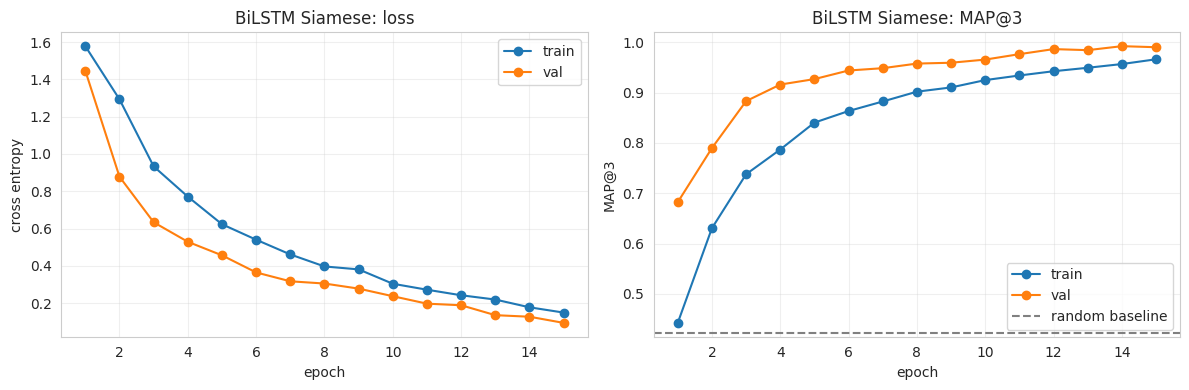

In [17]:
plot_history(lstm_trainer.history, "BiLSTM Siamese")

## Model 2: BiGRU with attention pooling

Reuses the same vocabulary and loaders as model 1.

In [18]:
class GRUCfg:
    NAME           = "bigru-attention"
    EMBED_DIM      = 300
    HIDDEN_DIM     = 256
    NUM_LAYERS     = 2
    DROPOUT        = 0.3
    EPOCHS         = 15
    LR             = 1e-3
    EMBED_LR_RATIO = 0.1


seed_everything(CFG.SEED)

gru_model = BiGRUAttention(len(vocab.word2id), GRUCfg)
print(f"trainable params: {sum(p.numel() for p in gru_model.parameters() if p.requires_grad):,}")

gru_trainer = Trainer(
    model          = gru_model,
    name           = GRUCfg.NAME,
    batch_kind     = "word",
    epochs         = GRUCfg.EPOCHS,
    lr             = GRUCfg.LR,
    embed_lr_ratio = GRUCfg.EMBED_LR_RATIO,
    scheduler      = "plateau",
    wandb_config   = as_dict(GRUCfg),
)

gru_trainer.fit(word_train_loader, word_val_loader)

trainable params: 4,048,726


bigru-attention epoch 1/15:   0%|          | 0/25 [00:00<?, ?it/s]

bigru-attention predict:   0%|          | 0/7 [00:00<?, ?it/s]

[bigru-attention] epoch 01/15  tr_loss=1.3823  tr_map=0.5451  vl_loss=0.8400  vl_map=0.8254  *best


bigru-attention epoch 2/15:   0%|          | 0/25 [00:00<?, ?it/s]

...

[bigru-attention] epoch 14/15  tr_loss=0.0326  tr_map=0.9933  vl_loss=0.0316  vl_map=0.9987


bigru-attention epoch 15/15:   0%|          | 0/25 [00:00<?, ?it/s]

bigru-attention predict:   0%|          | 0/7 [00:00<?, ?it/s]

[bigru-attention] epoch 15/15  tr_loss=0.0158  tr_map=0.9958  vl_loss=0.0374  vl_map=0.9987
[bigru-attention] best val MAP@3: 1.0000


[{'epoch': 1,
  'tr_loss': 1.3823493814468384,
  'tr_map': 0.5451042056083679,
  'vl_loss': 0.8400160585130964,
  'vl_map': 0.8254167437553406},
 {'epoch': 2,
  'tr_loss': 0.842550333738327,
  'tr_map': 0.7797916531562805,
  'vl_loss': 0.45777048809187754,
  'vl_map': 0.93708336353302},
 {'epoch': 3,
  'tr_loss': 0.5528661680221557,
  'tr_map': 0.8598958849906921,
  'vl_loss': 0.28422069762434277,
  'vl_map': 0.9762499928474426},
 {'epoch': 4,
  'tr_loss': 0.3446820843219757,
  'tr_map': 0.9215624928474426,
  'vl_loss': 0.180218120770795,
  'vl_map': 0.9841666221618652},
 {'epoch': 5,
  'tr_loss': 0.26060055613517763,
  'tr_map': 0.94447922706604,
  'vl_loss': 0.10963913532240051,
  'vl_map': 0.9929166436195374},
 {'epoch': 6,
  'tr_loss': 0.192322498857975,
  'tr_map': 0.9593750238418579,
  'vl_loss': 0.08958236474011626,
  'vl_map': 0.9908333420753479},
 {'epoch': 7,
  'tr_loss': 0.14824486330151557,
  'tr_map': 0.9702083468437195,
  'vl_loss': 0.04256806948355266,
  'vl_map': 0.9962

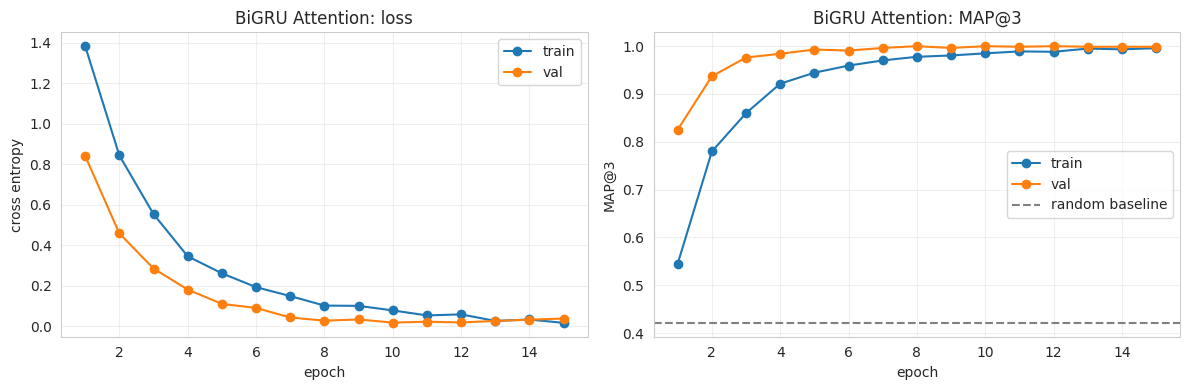

In [19]:
plot_history(gru_trainer.history, "BiGRU Attention")

In [20]:
# Garbage Collection
import gc

lstm_trainer.model = lstm_trainer.model.cpu()
lstm_trainer.base_model = lstm_trainer.base_model.cpu()
gru_trainer.model = gru_trainer.model.cpu()
gru_trainer.base_model = gru_trainer.base_model.cpu()

gc.collect()
torch.cuda.empty_cache()
print(f"reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")

reserved: 0.16 GB


## Model 3: DeBERTa v3 large with LoRA

Mixed precision plus gradient accumulation keeps this inside T4 memory.

In [21]:
class DebertaCfg:
    NAME           = "deberta-v3-large-lora"
    MODEL_NAME     = "microsoft/deberta-v3-large"
    MAX_LEN        = 256
    BATCH_SIZE     = 2 * max(N_GPUS, 1)
    GRAD_ACCUM     = 16
    EPOCHS         = 3
    LR             = 2e-4
    LORA_R         = 16
    LORA_ALPHA     = 32
    LORA_DROPOUT   = 0.1
    TARGET_MODULES = ["query_proj", "key_proj", "value_proj"]


hf_tokenizer = AutoTokenizer.from_pretrained(DebertaCfg.MODEL_NAME)


def make_hf_loader(df, has_labels, shuffle):
    ds = HFMCQDataset(df, hf_tokenizer, DebertaCfg.MAX_LEN, has_labels=has_labels)
    return DataLoader(ds, batch_size=DebertaCfg.BATCH_SIZE, shuffle=shuffle, num_workers=2, persistent_workers=True)


hf_train_loader = make_hf_loader(train_df, True,  True)
hf_val_loader   = make_hf_loader(val_df,   True,  False)
hf_test_loader  = make_hf_loader(test_df,  False, False)

print(f"hf loaders: train {len(hf_train_loader)}  "
      f"val {len(hf_val_loader)}  test {len(hf_test_loader)} batches")

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

hf loaders: train 400  val 100  test 125 batches


In [22]:
seed_everything(CFG.SEED)

deberta_model = DebertaLoRA(DebertaCfg)
deberta_model.print_trainable()

steps_per_epoch = int(np.ceil(len(hf_train_loader) / DebertaCfg.GRAD_ACCUM))

deberta_trainer = Trainer(
    model           = deberta_model,
    name            = DebertaCfg.NAME,
    batch_kind      = "hf",
    epochs          = DebertaCfg.EPOCHS,
    lr              = DebertaCfg.LR,
    grad_accum      = DebertaCfg.GRAD_ACCUM,
    use_amp         = True,
    scheduler       = "onecycle",
    steps_per_epoch = steps_per_epoch,
    wandb_config    = as_dict(DebertaCfg),
)

deberta_trainer.fit(hf_train_loader, hf_val_loader)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias

...

[deberta-v3-large-lora] epoch 02/3  tr_loss=1.4818  tr_map=0.5213  vl_loss=1.1318  vl_map=0.7983  *best


deberta-v3-large-lora epoch 3/3:   0%|          | 0/400 [00:00<?, ?it/s]

deberta-v3-large-lora predict:   0%|          | 0/100 [00:00<?, ?it/s]

[deberta-v3-large-lora] epoch 03/3  tr_loss=1.1965  tr_map=0.6827  vl_loss=0.9421  vl_map=0.8462  *best
[deberta-v3-large-lora] best val MAP@3: 0.8462


[{'epoch': 1,
  'tr_loss': 1.6057998657226562,
  'tr_map': 0.39802083373069763,
  'vl_loss': 1.5787701404094696,
  'vl_map': 0.6337500214576721},
 {'epoch': 2,
  'tr_loss': 1.4818090438842773,
  'tr_map': 0.5212500095367432,
  'vl_loss': 1.1318020391464234,
  'vl_map': 0.7983332872390747},
 {'epoch': 3,
  'tr_loss': 1.196501955986023,
  'tr_map': 0.6827083826065063,
  'vl_loss': 0.9421368661522865,
  'vl_map': 0.8462499976158142}]

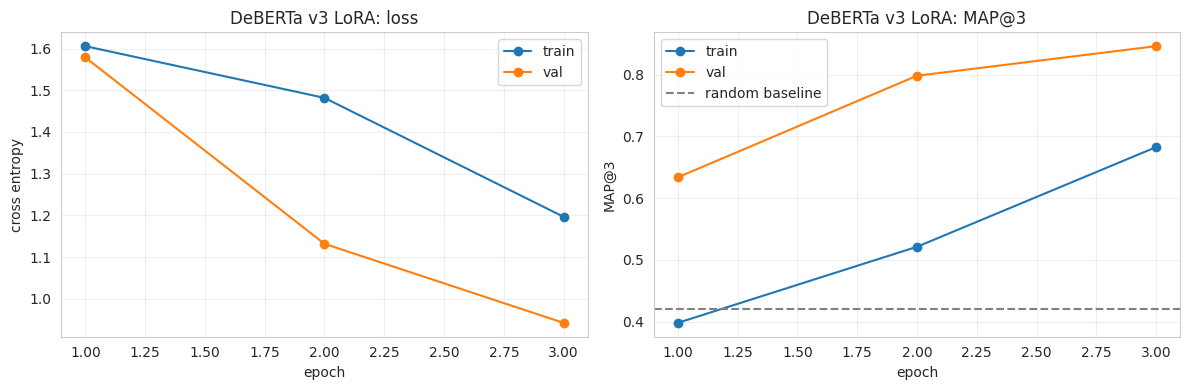

In [23]:
plot_history(deberta_trainer.history, "DeBERTa v3 LoRA")

## Model Comparison

In [24]:
MODELS = {
    LSTMCfg.NAME    : {"trainer": lstm_trainer,    "val": word_val_loader, "test": word_test_loader},
    GRUCfg.NAME     : {"trainer": gru_trainer,     "val": word_val_loader, "test": word_test_loader},
    DebertaCfg.NAME : {"trainer": deberta_trainer, "val": hf_val_loader,   "test": hf_test_loader},
}

summary = pd.DataFrame([
    {
        "model"       : name,
        "best_val_map": m["trainer"].best_val_map,
        "best_epoch"  : max(m["trainer"].history, key=lambda h: h["vl_map"])["epoch"],
        "final_tr_map": m["trainer"].history[-1]["tr_map"],
        "params"      : sum(p.numel() for p in m["trainer"].base_model.parameters()),
    }
    for name, m in MODELS.items()
]).sort_values("best_val_map", ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

                model  best_val_map  best_epoch  final_tr_map    params
      bigru-attention      1.000000           8      0.995833   4048726
       bilstm-siamese      0.992083          14      0.966042   4466005
deberta-v3-large-lora      0.846250           3      0.682708 438472706


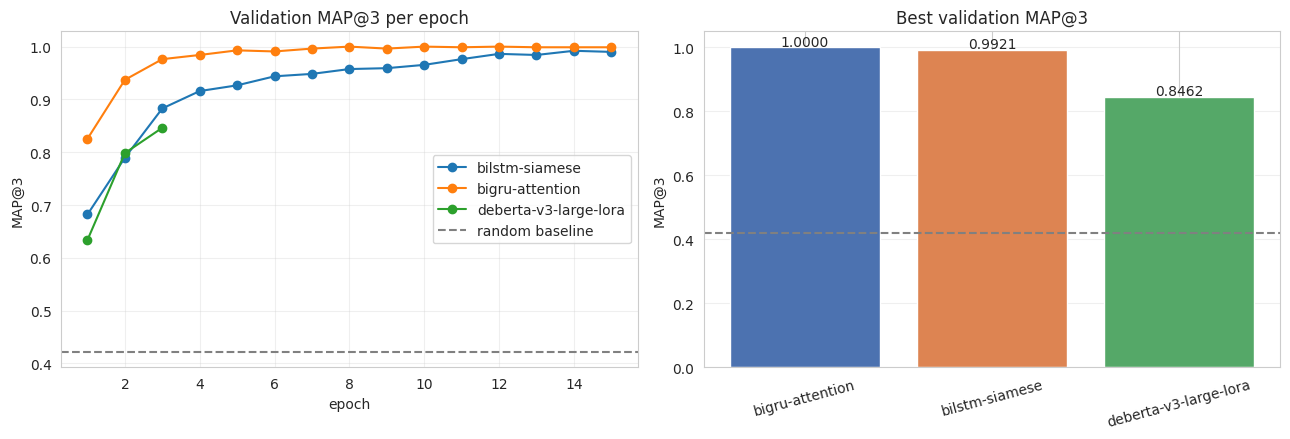

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for name, m in MODELS.items():
    hist = m["trainer"].history
    ax1.plot([h["epoch"] for h in hist], [h["vl_map"] for h in hist], marker="o", label=name)
ax1.axhline(0.4213, linestyle="--", color="gray", label="random baseline")
ax1.set_title("Validation MAP@3 per epoch")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MAP@3")
ax1.legend()
ax1.grid(True, alpha=0.3)

bars = ax2.bar(summary["model"], summary["best_val_map"], color=sns.color_palette("deep", len(summary)))
for b, v in zip(bars, summary["best_val_map"]):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.4f}", ha="center")
ax2.axhline(0.4213, linestyle="--", color="gray")
ax2.set_title("Best validation MAP@3")
ax2.set_ylabel("MAP@3")
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis="x", rotation=15)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Ensemble

Probabilities from each model are blended with weights tuned on validation. The alignment check must pass, otherwise the blend would mix up rows.

In [26]:
val_probs, val_labels_ref = {}, None

for name, m in MODELS.items():
    tr = m["trainer"]
    tr.model = tr.model.to(CFG.DEVICE)

    _, vl_map, logits, labels = tr.predict(m["val"], has_labels=True)
    val_probs[name] = F.softmax(logits, dim=-1)

    tr.model = tr.model.to("cpu")
    torch.cuda.empty_cache()

    if val_labels_ref is None:
        val_labels_ref = labels
    else:
        assert torch.equal(val_labels_ref, labels), f"val row order mismatch for {name}"
    print(f"{name}: val MAP@3 {vl_map:.4f}")

print("\nAlignment check passed, all models see the same validation rows in the same order.")

bilstm-siamese predict:   0%|          | 0/7 [00:00<?, ?it/s]

bilstm-siamese: val MAP@3 0.9921


bigru-attention predict:   0%|          | 0/7 [00:00<?, ?it/s]

bigru-attention: val MAP@3 1.0000


deberta-v3-large-lora predict:   0%|          | 0/100 [00:00<?, ?it/s]

deberta-v3-large-lora: val MAP@3 0.8462

Alignment check passed, all models see the same validation rows in the same order.


In [27]:
from itertools import product

names = list(MODELS.keys())
step  = 0.05

# Every weight combination on the simplex, so this works for any number of models.
combos = [w for w in product(np.arange(0.0, 1.0 + step / 2, step), repeat=len(names))
          if abs(sum(w) - 1.0) < 1e-9]
print(f"searching {len(combos)} weight combinations over {len(names)} models")

best_w, best_map = None, 0.0
for w in combos:
    blended = sum(wi * val_probs[n] for wi, n in zip(w, names))
    score   = map_at_3(blended, val_labels_ref)
    if score > best_map:
        best_map, best_w = score, w

ENSEMBLE_WEIGHTS = {n: float(wi) for n, wi in zip(names, best_w)}
assert abs(sum(ENSEMBLE_WEIGHTS.values()) - 1.0) < 1e-6

print("Tuned ensemble weights:")
for n, w in ENSEMBLE_WEIGHTS.items():
    print(f"  {n:<24} {w:.2f}")
print(f"\nEnsemble val MAP@3: {best_map:.4f}")
print(f"Best single model:  {summary['best_val_map'].max():.4f}")
print(f"Gain over best single: {best_map - summary['best_val_map'].max():+.4f}")

searching 231 weight combinations over 3 models
Tuned ensemble weights:
  bilstm-siamese           0.00
  bigru-attention          0.50
  deberta-v3-large-lora    0.50

Ensemble val MAP@3: 1.0000
Best single model:  1.0000
Gain over best single: +0.0000


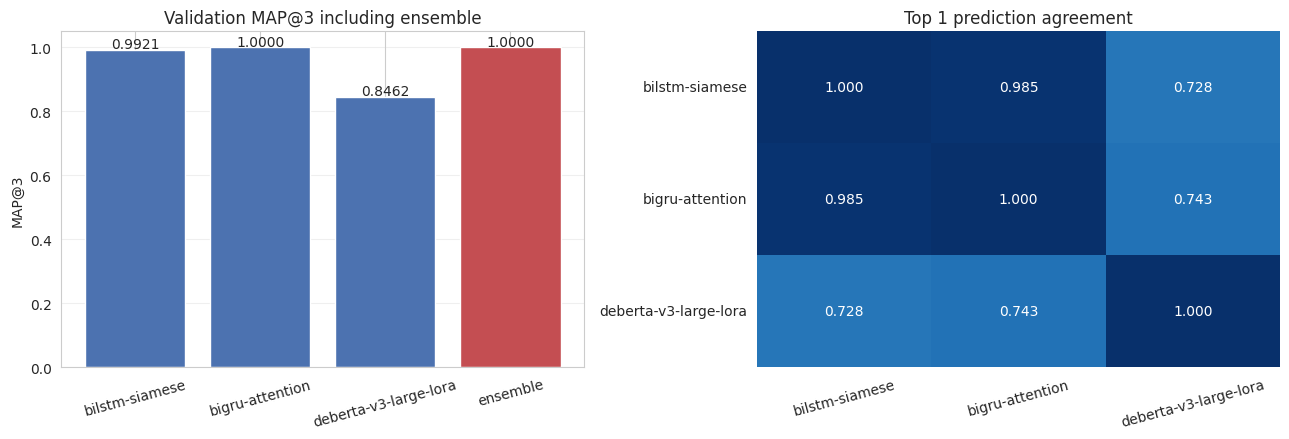

Lower agreement between models means more room for the ensemble to help.


In [28]:
val_ensemble = sum(ENSEMBLE_WEIGHTS[n] * val_probs[n] for n in names)

scores = {n: map_at_3(val_probs[n], val_labels_ref) for n in names}
scores["ensemble"] = map_at_3(val_ensemble, val_labels_ref)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ["#4C72B0"] * len(names) + ["#C44E52"]
bars = ax1.bar(list(scores.keys()), list(scores.values()), color=colors)
for b, v in zip(bars, scores.values()):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.4f}", ha="center")
ax1.set_title("Validation MAP@3 including ensemble")
ax1.set_ylabel("MAP@3")
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis="x", rotation=15)
ax1.grid(True, alpha=0.3, axis="y")

preds = {n: val_probs[n].argmax(dim=-1) for n in names}
agree = np.zeros((len(names), len(names)))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        agree[i, j] = (preds[a] == preds[b]).float().mean()

sns.heatmap(agree, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=names, yticklabels=names, ax=ax2, cbar=False)
ax2.set_title("Top 1 prediction agreement")
plt.setp(ax2.get_xticklabels(), rotation=15)
plt.setp(ax2.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Lower agreement between models means more room for the ensemble to help.")

## Final Selection

Set FINAL_CHOICE below to whichever candidate scored best, then run the last cell to write submission.csv.

In [29]:
candidate_scores = pd.DataFrame(
    [{"candidate": k, "val_map3": v} for k, v in scores.items()]
).sort_values("val_map3", ascending=False).reset_index(drop=True)

print(candidate_scores.to_string(index=False))
print(f"\nAvailable choices: {list(scores.keys())}")

            candidate  val_map3
      bigru-attention  1.000000
             ensemble  1.000000
       bilstm-siamese  0.992083
deberta-v3-large-lora  0.846250

Available choices: ['bilstm-siamese', 'bigru-attention', 'deberta-v3-large-lora', 'ensemble']


In [30]:
# Change this to any name printed above, for example "bilstm-siamese" or "ensemble".
FINAL_CHOICE = "ensemble"

assert FINAL_CHOICE in list(scores.keys()), f"unknown choice: {FINAL_CHOICE}"
print(f"Selected: {FINAL_CHOICE}  (val MAP@3 {scores[FINAL_CHOICE]:.4f})")

Selected: ensemble  (val MAP@3 1.0000)


In [31]:
test_probs = {}
for name, m in MODELS.items():
    tr = m["trainer"]
    tr.model = tr.model.to(CFG.DEVICE)

    _, _, logits, _ = tr.predict(m["test"], has_labels=False)
    test_probs[name] = F.softmax(logits, dim=-1)

    tr.model = tr.model.to("cpu")
    torch.cuda.empty_cache()
    print(f"{name}: test probs {tuple(test_probs[name].shape)}")

for name, probs in test_probs.items():
    assert len(probs) == len(test_df), f"row count mismatch for {name}"

bilstm-siamese predict:   0%|          | 0/8 [00:00<?, ?it/s]

bilstm-siamese: test probs (500, 5)


bigru-attention predict:   0%|          | 0/8 [00:00<?, ?it/s]

bigru-attention: test probs (500, 5)


deberta-v3-large-lora predict:   0%|          | 0/125 [00:00<?, ?it/s]

deberta-v3-large-lora: test probs (500, 5)


In [32]:
if FINAL_CHOICE == "ensemble":
    final_probs = sum(ENSEMBLE_WEIGHTS[n] * test_probs[n] for n in names)
else:
    final_probs = test_probs[FINAL_CHOICE]

top3 = torch.argsort(final_probs, dim=-1, descending=True)[:, :3].tolist()
preds = [" ".join(IDX_TO_LABEL[i] for i in row) for row in top3]

submission = pd.DataFrame({"ID": test_df["id"].values, "Prediction": preds})
submission.to_csv("submission.csv", index=False)

print(f"submission.csv written from: {FINAL_CHOICE}")
print(f"rows: {len(submission)}")
print(submission.head(10).to_string(index=False))

submission.csv written from: ensemble
rows: 500
 ID Prediction
  1      A E D
  2      B D C
  3      B E C
  4      E B A
  5      C D A
  6      D A B
  7      E C D
  8      B E C
  9      C E B
 10      B E C
